# Stochastic Processes and Realized Time Series

Notebooks 00–05 developed a distributional description of financial returns, moving from population models to estimation and out-of-sample evaluation. Those descriptions pooled returns across dates. They described possible values and their probabilities, but left the ordering of observations outside the model. Notebook 05 showed that a good in-sample distributional fit need not yield accurate future moments or downside risk.

I now retain that ordering. The question becomes whether past observations help describe future returns and their uncertainty. A stochastic process provides the framework, while the observed time series is one finite realization of that process. This extends the distributional analysis to include dependence across time. Out-of-sample discrepancies alone do not establish that dependence.

I introduce the process, distinguish it from one observed time series, and compare population properties with summaries calculated from a finite history. The population-versus-sample distinction remains central. Notebook 07 then asks when these properties are stable over time and when one long history can reveal them.


In [1]:
from pathlib import Path
import sys
repository = Path.cwd()
if not (repository / "src" / "finstats").is_dir():
    repository = repository.parent
if not (repository / "src" / "finstats").is_dir():
    raise RuntimeError("Run from the repository root or notebooks directory")
sys.path.insert(0, str(repository / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

plt.rcParams.update({
    "figure.figsize": (7,4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "font.size": 11, "axes.titlesize": 12,
    "legend.frameon": False, "lines.linewidth": 1.8,
})

from finstats.diagnostics import sample_autocovariance, sample_autocorrelation


## 1. Stochastic Processes

**Definition: stochastic process.** A discrete-time stochastic process is a collection of random variables
$$\{Y_t\}_{t\in\mathbb Z}=\{\ldots,Y_{-1},Y_0,Y_1,\ldots\}.$$
At a fixed time, $Y_t$ is a random variable. A trajectory $\{y_t\}$ is a possible history. For every finite set of time points, the joint distribution
$$F_{Y_{t_1},\ldots,Y_{t_k}}(y_1,\ldots,y_k)$$
is defined. These finite-dimensional distributions include temporal dependence, which individual marginal distributions do not specify.

For financial returns, each $Y_t$ can represent the uncertain return over one interval. Dependence concerns the joint behavior of returns at different dates, not just their individual distributions.

## 2. Realized Time Series

**Definition: time series.** A time series $y_1,\ldots,y_n$ is one partial realization of the underlying process. The DGP can generate many other histories with the same population properties.

For illustration, I generate ten independent histories of length 150 from an IID $N(0,1)$ process, with seed 501. One highlighted history represents the observed series. The other paths show possibilities that would not be observed alongside it in an actual single-series dataset.

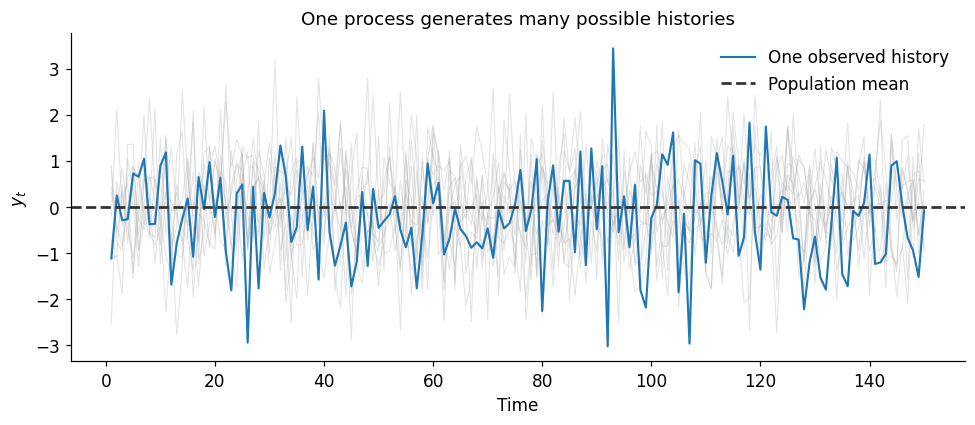

In [2]:
histories = np.random.default_rng(501).normal(size=(10, 150))
observed = histories[0]
times = np.arange(1, 151)
fig, ax = plt.subplots(figsize=(9, 4))
for path in histories[1:]:
    ax.plot(times, path, color="0.65", alpha=.3, linewidth=.7)
ax.plot(times, observed, color="C0", linewidth=1.4, label="One observed history")
ax.axhline(0, color="0.2", linestyle="--", label="Population mean")
ax.set(xlabel="Time", ylabel="$y_t$", title="One process generates many possible histories")
ax.legend()
fig.tight_layout()
plt.show()

## 3. Population Properties

When second moments exist, the process has the following population functions.

### Mean and Variance Functions

The **mean function** describes the expected value at each date, and the **variance function** describes dispersion around it:
$$\mu(t)=E[Y_t],\qquad\sigma^2(t)=E[(Y_t-\mu(t))^2].$$

### Autocovariance and Autocorrelation Functions

The **autocovariance function** measures linear dependence between values at two dates:
$$\gamma(t,s)=E[(Y_t-\mu(t))(Y_s-\mu(s))].$$
Its diagonal is the variance, $\gamma(t,t)=\sigma^2(t)$. The **autocorrelation function (ACF)** expresses this dependence on a scale independent of the measurement units:
$$\rho(t,s)=\frac{\gamma(t,s)}{\sqrt{\gamma(t,t)\gamma(s,s)}}.$$
Correlation requires positive variances. These functions can depend on calendar time as well as the separation between observations. They describe second-order properties, not necessarily the full joint law.

In the simulated IID $N(0,1)$ process, $\mu(t)=0$ and $\sigma^2(t)=1$ at every date. Distinct dates have covariance and correlation zero. These are known properties of the generating model, not estimates obtained from the highlighted history.


## 4. Sample Properties

One realized history provides sample quantities. It does not reveal the population functions directly. I summarize its values and their lagged relationships using the course's sample definitions.

### Sample Mean and Variance

For observations $y_1,\ldots,y_n$, the **sample mean** and **sample variance** are
$$\bar y=\frac1n\sum_{t=1}^n y_t,\qquad
s^2=\frac1{n-1}\sum_{t=1}^n(y_t-\bar y)^2.$$
These are the same finite-sample summaries introduced earlier. The denominator correction does not generally make variance estimation unbiased when observations are dependent.

### Sample Autocovariance and Autocorrelation

At lag $j$, with $0\le j<n$, the **sample autocovariance** and **sample autocorrelation** are
$$\hat\gamma_j=\frac1{n-j}\sum_{t=j+1}^n(y_t-\bar y)(y_{t-j}-\bar y),\qquad
\hat\rho_j=\frac{\hat\gamma_j}{\hat\gamma_0}.$$
The lag-zero value uses denominator $n$, so $s^2=n\hat\gamma_0/(n-1)$. Other software may use denominator $n$ at every lag; I retain the course convention here. With the adjusted denominator, finite-sample ratios need not satisfy every property of a population correlation function.

### Illustration: Population and Observed History

For illustration, I compare the highlighted history with its known generating model. The table reports both variance conventions explicitly. The figure asks whether a finite IID history has exactly zero sample dependence. It generally does not: sample autocovariances and correlations fluctuate around their population values. No independence test is being performed.


,Population,Observed history
Mean,0.0,-0.2449
Variance (denominator n),1.0,1.0957
Variance (denominator n−1),1.0,1.1030
Lag-one covariance,0.0,-0.1572
Lag-one correlation,0.0,-0.1435


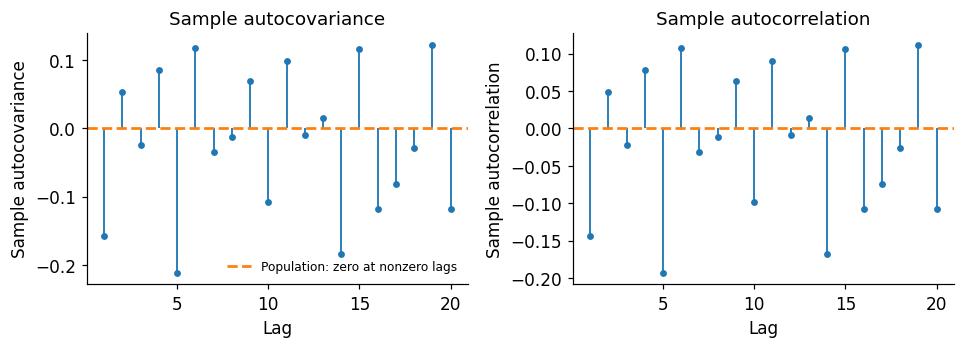

In [3]:
display(pd.DataFrame({
    "Population": [0., 1., 1., 0., 0.],
    "Observed history": [np.mean(observed), sample_autocovariance(observed, 0),
                         np.var(observed, ddof=1), sample_autocovariance(observed, 1),
                         sample_autocorrelation(observed, 1)],
}, index=["Mean", "Variance (denominator n)", "Variance (denominator n−1)",
          "Lag-one covariance", "Lag-one correlation"]).round(4))
fig, axes = plt.subplots(1, 2, figsize=(9, 3.3))
lags = np.arange(1, 21)
for ax, values, label in [
    (axes[0], [sample_autocovariance(observed, int(j)) for j in lags], "Sample autocovariance"),
    (axes[1], [sample_autocorrelation(observed, int(j)) for j in lags], "Sample autocorrelation"),
]:
    ax.vlines(lags, 0, values, color="C0", linewidth=1.2)
    ax.scatter(lags, values, color="C0", s=12)
    ax.axhline(0, color="C1", linestyle="--", label="Population: zero at nonzero lags")
    ax.set(xlabel="Lag", ylabel=label, title=label)
axes[0].legend(fontsize=8)
fig.tight_layout()
plt.show()


One realized history provides observations, not direct knowledge of its generating process. Pooled moments summarize values, while lagged moments also describe their ordering. The next notebook asks which population properties can remain stable across time and what is needed to learn them from a single history.